# Module 2 — Dynamic Linear Regression (M2)
## Topic 8: Adding Exogenous Variables to the AR(p) Benchmark

**What this notebook covers**

| Step | Question | Tool |
|------|----------|------|
| 1 | What does M2 add to AR(p)? | ARX model equation |
| 2 | Why should $Z_t$ help? | Economic rationale |
| 3 | Is $Z_t$ usable? | The timing trap |
| 4 | Is $Z_t$ stationary? | ADF on the predictor |
| 5 | How many lags for both $y$ and $z$? | 2D information criterion grid |
| 6 | How do I estimate M2? | OLS, coefficient interpretation |
| 7 | How do I forecast $h$ steps ahead? | Direct ARX forecast |
| 8 | Does M2 beat the AR(p) benchmark? | Recursive OOS evaluation |

**Three applied examples**
- 📊 **Okun's Law** — US GDP growth predicted by changes in unemployment (1959–2009)
- 📊 **Phillips Curve** — US inflation predicted by unemployment rate, including **the timing trap**
- 📈 **CAPM beta** — Food-sector excess returns predicted by market excess returns (1960–2002)

> Replace data-loading cells with `fredapi` or `yfinance` in your own environment — the model code is identical.


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings, requests, io
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 11})
BLUE, RED, GREEN, ORANGE, PURPLE = '#2166ac','#d6604d','#4dac26','#f4a582','#762a83'
GREY = '#636363'

def rmse(e): return np.sqrt(np.mean(np.array(e)**2))
def mae(e):  return np.mean(np.abs(np.array(e)))

print("Imports OK")

Imports OK


In [2]:
# ── Dataset 1: US Quarterly Macro (1959Q1–2009Q3) ────────────────────────────
#    Equivalent to FRED: GDPC1, UNRATE, CPIAUCSL

macro_raw = sm.datasets.macrodata.load_pandas().data
macro_raw['period'] = macro_raw.apply(
    lambda r: pd.Period(year=int(r.year), quarter=int(r.quarter), freq='Q'), axis=1)
macro = macro_raw.set_index('period')

macro['gdp_growth'] = np.log(macro['realgdp']).diff()  * 100   # Δlog * 100
macro['inv_growth']  = np.log(macro['realinv']).diff()  * 100
macro['cons_growth'] = np.log(macro['realcons']).diff() * 100
macro['d_unemp']    = macro['unemp'].diff()                     # Δ unemployment rate
# Note: macro['infl'] is already in %, directly from the dataset

print("US Macro:", macro.shape)
macro[['gdp_growth','d_unemp','infl','unemp','tbilrate']].dropna().tail(4)

US Macro: (203, 18)


,gdp_growth,d_unemp,infl,unemp,tbilrate
period,,,,,
2008Q4,-1.380483,0.9,-8.79,6.9,0.12
2009Q1,-1.661198,1.2,0.94,8.1,0.22
2009Q2,-0.185125,1.1,3.37,9.2,0.18
2009Q3,0.686219,0.4,3.56,9.6,0.12


In [3]:
# ── Dataset 2: CAPM Monthly Returns (1960M1–2002M12) ─────────────────────────
#    Equivalent to yfinance excess returns vs. market
#    rfood = food sector return, rmrf = market excess return, rf = risk-free rate

capm = sm.datasets.get_rdataset('Capm', 'Ecdat').data
capm.index = pd.period_range(start='1960-01', periods=len(capm), freq='M')

# Compute excess returns: r_excess = r_sector - r_f
capm['rfood_excess'] = capm['rfood'] - capm['rf']   # food sector above risk-free
capm['rdur_excess']  = capm['rdur']  - capm['rf']   # durables sector

print("CAPM monthly:", capm.shape, "| 1960M1 –", capm.index[-1])
capm[['rfood_excess','rmrf','rf']].tail(3)

CAPM monthly: (516, 7) | 1960M1 – 2002-12


,rfood_excess,rmrf,rf
2002-10,4.59,7.30,0.14
2002-11,-1.43,5.96,0.12
2002-12,-1.13,-5.42,0.11


In [4]:
# ── Dataset 3: US Quarterly Changes (1970Q1–2016Q3) ─────────────────────────
#    uschange: Consumption, Income, Production, Savings, Unemployment (% changes)

uschange = sm.datasets.get_rdataset('uschange', 'fpp2').data
uschange.index = pd.period_range(start='1970Q1', periods=len(uschange), freq='Q')
print("uschange:", uschange.shape)
uschange.tail(3)

uschange: (187, 5)


,Consumption,Income,Production,Savings,Unemployment
2016Q1,0.404682,0.519025,-0.417930,2.236534,0.0
2016Q2,1.047707,0.723721,-0.203319,-2.721501,-0.1
2016Q3,0.729598,0.644701,0.474918,-0.572858,0.0


---
## Step 1 — What Does M2 Add? The ARX Model Equation

### From AR(p) to ARX(p,q)

The AR(p) benchmark only uses the series' own history. The **dynamic linear regression (M2)** extends it by including $q$ lagged values of an external predictor $Z_t$:

$$\boxed{y_t = c + \underbrace{\sum_{i=1}^{p} \phi_i\, y_{t-i}}_{\text{AR part}} + \underbrace{\sum_{j=1}^{q} \psi_j\, Z_{t-j}}_{\text{exogenous part}} + \varepsilon_t, \qquad \varepsilon_t \sim \text{WN}(0,\sigma^2)}$$

This is also written as $\phi(L)\,y_t = c + \psi(L)\,Z_t + \varepsilon_t$, where $\phi(L)$ and $\psi(L)$ are lag polynomials.

**The $h$-step-ahead direct forecast** (seminar equation 5):

$$\hat{y}_{t+h|t} = \hat{c} + \sum_{i=1}^{p} \hat\phi_i\, y_{t+1-i} + \sum_{j=1}^{q} \hat\psi_j\, Z_{t+1-j}$$

The key design decision: *which* $Z_t$, *how many* lags, and *when* is it available?

### The three ingredients of a good $Z_t$

| Requirement | Why it matters | How to check |
|-------------|---------------|--------------|
| **Economic rationale** | Spurious correlations are everywhere | Theory first |
| **Timing** | $Z_t$ must be available *before* $y_t$ is forecasted | Publication calendar |
| **Stationarity** | OLS properties require $Z_t$ to be stationary | ADF test |


In [5]:
# ── Side-by-side: AR(2) vs ARX(2,1) — what changes in the design matrix ─────

gdp    = macro['gdp_growth'].dropna()
d_unemp = macro['d_unemp'].dropna()

# Align the two series
df = pd.DataFrame({'y': gdp, 'z': d_unemp}).dropna()
y = df['y'].values
z = df['z'].values
T = len(y)
p, q = 2, 1

# AR(2) design matrix: X = [1, y_{t-1}, y_{t-2}]
X_ar = np.column_stack([np.ones(T-p), y[p-1:-1], y[p-2:-2]])

# ARX(2,1) design matrix: X = [1, y_{t-1}, y_{t-2}, z_{t-1}]
X_arx = np.column_stack([np.ones(T-p), y[p-1:-1], y[p-2:-2], z[p-1:-1]])

Y = y[p:]

print("Design matrix comparison: AR(2) vs ARX(2,1) on GDP growth / d_unemployment")
print("\nAR(2) — X columns:  ['const', 'y_{t-1}', 'y_{t-2}']")
print(pd.DataFrame(X_ar[:3], columns=['const', 'y_{t-1}', 'y_{t-2}']).round(3).to_string(index=False))

print("\nARX(2,1) — X columns:  ['const', 'y_{t-1}', 'y_{t-2}', 'z_{t-1}']")
print(pd.DataFrame(X_arx[:3], columns=['const','y_{t-1}','y_{t-2}','z_{t-1}']).round(3).to_string(index=False))

# OLS estimates
b_ar  = np.linalg.solve(X_ar.T  @ X_ar,  X_ar.T  @ Y)
b_arx = np.linalg.solve(X_arx.T @ X_arx, X_arx.T @ Y)
resid_ar  = Y - X_ar  @ b_ar
resid_arx = Y - X_arx @ b_arx

print(f"\nAR(2)  estimates:  c={b_ar[0]:.4f},  φ1={b_ar[1]:.4f},  φ2={b_ar[2]:.4f}")
print(f"ARX(2,1) estimates: c={b_arx[0]:.4f},  φ1={b_arx[1]:.4f},  φ2={b_arx[2]:.4f},  ψ1={b_arx[3]:.4f}")
print(f"\nIn-sample R²:  AR(2)={1-np.var(resid_ar)/np.var(Y):.4f},  ARX={1-np.var(resid_arx)/np.var(Y):.4f}")
print(f"Note: ψ1 = {b_arx[3]:.4f} — a 1pp rise in unemployment last quarter")
print(f"      is associated with a {b_arx[3]:.3f}pp change in GDP growth this quarter")

Design matrix comparison: AR(2) vs ARX(2,1) on GDP growth / d_unemployment

AR(2) — X columns:  ['const', 'y_{t-1}', 'y_{t-2}']
 const  y_{t-1}  y_{t-2}
   1.0   -0.119    2.494
   1.0    0.349   -0.119
   1.0    2.219    0.349

ARX(2,1) — X columns:  ['const', 'y_{t-1}', 'y_{t-2}', 'z_{t-1}']
 const  y_{t-1}  y_{t-2}  z_{t-1}
   1.0   -0.119    2.494      0.2
   1.0    0.349   -0.119      0.3
   1.0    2.219    0.349     -0.4

AR(2)  estimates:  c=0.4410,  φ1=0.2687,  φ2=0.1594
ARX(2,1) estimates: c=0.6463,  φ1=0.1224,  φ2=0.0578,  ψ1=-0.6686

In-sample R²:  AR(2)=0.1249,  ARX=0.1518
Note: ψ1 = -0.6686 — a 1pp rise in unemployment last quarter
      is associated with a -0.669pp change in GDP growth this quarter


---
## Step 2 — Why Should $Z_t$ Help? Three Economic Relationships

Before running a single regression, you need a theoretical reason to include $Z_t$. Including random variables will always improve in-sample fit — the question is whether they help out-of-sample.

### Relationship 1 — Okun's Law (GDP ↔ Unemployment)

$$\text{GDP growth}_t \approx -\kappa \cdot \Delta\text{Unemployment}_t + \text{trend}$$

**Intuition**: when firms lay off workers, output is falling; when they hire, output is rising. A 1pp rise in unemployment is typically associated with a 2–3pp drop in GDP growth.

### Relationship 2 — Phillips Curve (Inflation ↔ Unemployment)

$$\pi_t \approx \pi^e_{t} - \alpha(\text{Unemployment}_t - \text{NAIRU})$$

**Intuition**: when unemployment is below the natural rate, labour markets are tight, wages rise, and inflation increases. The original Phillips (1958) paper found this trade-off in UK data.

### Relationship 3 — CAPM Beta (Sector returns ↔ Market returns)

$$r_{i,t} - r_{f,t} = \alpha_i + \beta_i (r_{m,t} - r_{f,t}) + \varepsilon_{i,t}$$

**Intuition**: a sector's excess return moves with the market. $\beta > 1$ means the sector amplifies market swings; $\beta < 1$ means it is defensive. Crucially, the market return and sector return are available **at the same time** — no timing problem.


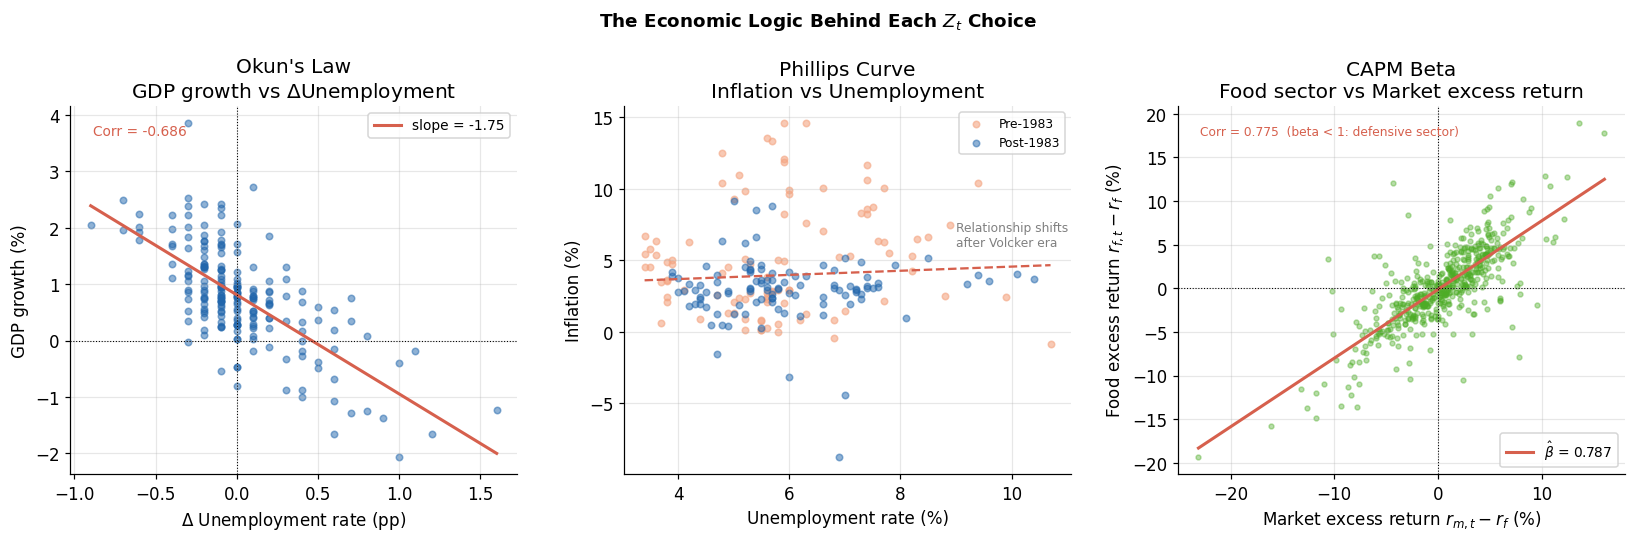

In [6]:
# ── Visualize all three relationships ────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("The Economic Logic Behind Each $Z_t$ Choice",
             fontsize=12, fontweight='bold')

# ── Okun's Law ────────────────────────────────────────────────────────────────
df_okun = pd.DataFrame({
    'gdp_growth': macro['gdp_growth'],
    'd_unemp':    macro['d_unemp'],
}).dropna()

ax = axes[0]
ax.scatter(df_okun['d_unemp'], df_okun['gdp_growth'],
           s=18, color=BLUE, alpha=0.5)
# Regression line
x_okun = df_okun['d_unemp'].values
b_ok   = np.polyfit(x_okun, df_okun['gdp_growth'].values, 1)
xr     = np.linspace(x_okun.min(), x_okun.max(), 100)
ax.plot(xr, np.polyval(b_ok, xr), color=RED, lw=2,
        label=fr'slope = {b_ok[0]:.2f}')
ax.axhline(0, color='black', lw=0.7, ls=':')
ax.axvline(0, color='black', lw=0.7, ls=':')
ax.set_title("Okun's Law\nGDP growth vs $\\Delta$Unemployment")
ax.set_xlabel(r"$\Delta$ Unemployment rate (pp)")
ax.set_ylabel("GDP growth (%)")
ax.legend(fontsize=9)
corr_ok = df_okun.corr().iloc[0,1]
ax.annotate(f"Corr = {corr_ok:.3f}", xy=(0.05, 0.92),
            xycoords='axes fraction', fontsize=9, color=RED)

# ── Phillips Curve ────────────────────────────────────────────────────────────
df_pc = pd.DataFrame({
    'infl':  macro['infl'],
    'unemp': macro['unemp'],
}).dropna()

ax = axes[1]
# Pre/post 1983 (Volcker disinflation)
pre  = df_pc[df_pc.index < pd.Period('1983Q1','Q')]
post = df_pc[df_pc.index >= pd.Period('1983Q1','Q')]
ax.scatter(pre['unemp'],  pre['infl'],  s=18, color=ORANGE, alpha=0.6, label='Pre-1983')
ax.scatter(post['unemp'], post['infl'], s=18, color=BLUE,   alpha=0.5, label='Post-1983')
b_pc = np.polyfit(df_pc['unemp'].values, df_pc['infl'].values, 1)
xr_pc = np.linspace(df_pc['unemp'].min(), df_pc['unemp'].max(), 100)
ax.plot(xr_pc, np.polyval(b_pc, xr_pc), color=RED, lw=1.5, ls='--')
ax.set_title("Phillips Curve\nInflation vs Unemployment")
ax.set_xlabel("Unemployment rate (%)")
ax.set_ylabel("Inflation (%)")
ax.legend(fontsize=8)
ax.annotate("Relationship shifts\nafter Volcker era",
            xy=(9, 6), fontsize=8, color='gray')

# ── CAPM Beta ─────────────────────────────────────────────────────────────────
ax = axes[2]
ax.scatter(capm['rmrf'], capm['rfood_excess'],
           s=10, color=GREEN, alpha=0.4)
b_capm = np.polyfit(capm['rmrf'].values, capm['rfood_excess'].values, 1)
xr_c   = np.linspace(capm['rmrf'].min(), capm['rmrf'].max(), 100)
ax.plot(xr_c, np.polyval(b_capm, xr_c), color=RED, lw=2,
        label=fr'$\hat\beta$ = {b_capm[0]:.3f}')
ax.axhline(0, color='black', lw=0.7, ls=':')
ax.axvline(0, color='black', lw=0.7, ls=':')
ax.set_title(r"CAPM Beta" "\nFood sector vs Market excess return")
ax.set_xlabel(r"Market excess return $r_{m,t} - r_f$ (%)")
ax.set_ylabel(r"Food excess return $r_{f,t} - r_f$ (%)")
ax.legend(fontsize=9)
corr_c = capm[['rfood_excess','rmrf']].corr().iloc[0,1]
ax.annotate(f"Corr = {corr_c:.3f}  (beta < 1: defensive sector)",
            xy=(0.05, 0.92), xycoords='axes fraction', fontsize=8, color=RED)

plt.tight_layout()
plt.show()

---
## Step 3 — The Timing Trap: When Is $Z_t$ Actually Available?

This is **the most common mistake** in applied forecasting. The seminar is explicit:

> *"If $Z_t$ is published after $Y_t$, the forecast is not possible in real time."*

The rule: to forecast $y_{t+1}$ standing at time $t$, you can only use information available **at time $t$ or earlier**.

### Publication calendars in practice

| Variable | Published when | Usable to forecast |
|----------|---------------|-------------------|
| **GDP growth** (quarterly) | ~30 days after quarter ends | GDP of *next* quarter (at best) |
| **Unemployment rate** (monthly) | First Friday of next month | 1–2 months ahead of quarterly GDP |
| **CPI inflation** (monthly) | ~15 days after month ends | Near-concurrent |
| **Stock returns** (daily) | End of trading day | Next day's returns (with caution) |
| **Market return** $r_{m,t}$ | End of day $t$ | Sector return on **same day** $t$ |

### The two cases

$$\text{Case A — use lagged } Z_t: \quad \hat{y}_{t+1|t} = c + \phi_1 y_t + \cdots + \psi_1 Z_{t-0}$$

Wait — even $Z_t$ here means $Z$ at the *current* period, which may not yet be released. Be careful: for quarterly data, if $Z_t$ is released with a 1-quarter lag, you must use $Z_{t-1}$.

$$\text{Case B — same-day / same-period (justified)}: \quad r_{\text{sector},t} = \alpha + \beta\, r_{m,t} + \varepsilon_t$$

Market and sector prices are both observed at close of business on day $t$ — no timing violation.


In [7]:
# ── The timing trap: a concrete illustration ─────────────────────────────────

print("=" * 65)
print("THE TIMING TRAP — US Inflation (Phillips Curve Example)")
print("=" * 65)
lines = [
    "Standing at end of 2008-Q2, you want to forecast inflation for 2008-Q3.",
    "",
    "What do you have?",
    "  - Inflation 2008-Q2: available",
    "  - Unemployment 2008-Q2: available (published July 2008)",
    "  - GDP growth 2008-Q2: may NOT be available (Flash estimate)",
    "",
    "Correct model (uses z_{t-1}, available at forecast origin):",
    "  pi_{t+1} = c + phi_1*pi_t + psi_1*unemp_t + eps_{t+1}",
    "",
    "WRONG model (uses z_t contemporaneously — future info!):",
    "  pi_t = c + phi_1*pi_{t-1} + psi_0*unemp_t + eps_t",
    "  -> unemp_t not released until AFTER quarter t ends",
]
for line in lines: print(line)

print("=" * 65)
print("THE TIMING TRAP — CAPM Example (No Problem Here)")
print("=" * 65)
capm_lines = [
    "Standing at end of trading day t, you observe:",
    "  - Market return r_{m,t}: YES (market closes)",
    "  - Food sector return r_{food,t}: YES (same time)",
    "",
    "Contemporaneous use is justified:",
    "  r_{food,t} - r_f = alpha + beta*(r_{m,t} - r_f) + eps_t",
    "",
    "Both sides are observed at the same time -> no timing violation.",
    "This is why CAPM uses contemporaneous market returns.",
]
for line in capm_lines: print(line)

THE TIMING TRAP — US Inflation (Phillips Curve Example)
Standing at end of 2008-Q2, you want to forecast inflation for 2008-Q3.

What do you have?
  - Inflation 2008-Q2: available
  - Unemployment 2008-Q2: available (published July 2008)
  - GDP growth 2008-Q2: may NOT be available (Flash estimate)

Correct model (uses z_{t-1}, available at forecast origin):
  pi_{t+1} = c + phi_1*pi_t + psi_1*unemp_t + eps_{t+1}

WRONG model (uses z_t contemporaneously — future info!):
  pi_t = c + phi_1*pi_{t-1} + psi_0*unemp_t + eps_t
  -> unemp_t not released until AFTER quarter t ends
THE TIMING TRAP — CAPM Example (No Problem Here)
Standing at end of trading day t, you observe:
  - Market return r_{m,t}: YES (market closes)
  - Food sector return r_{food,t}: YES (same time)

Contemporaneous use is justified:
  r_{food,t} - r_f = alpha + beta*(r_{m,t} - r_f) + eps_t

Both sides are observed at the same time -> no timing violation.
This is why CAPM uses contemporaneous market returns.


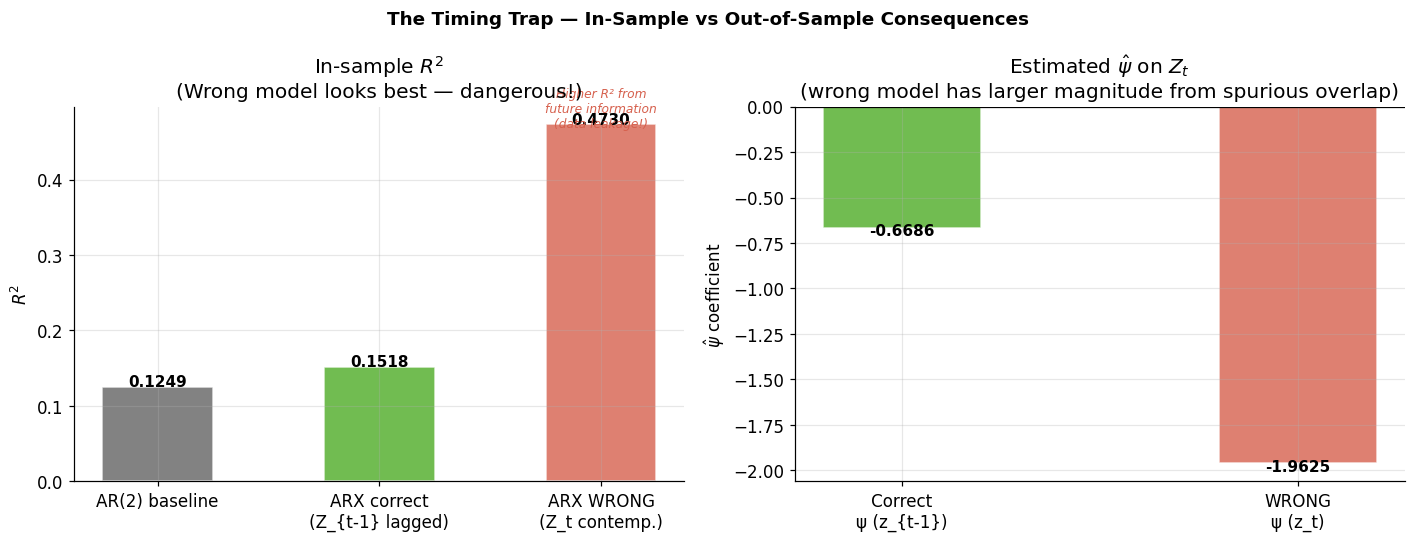

Key lesson:
  Correct ARX (z_{t-1}) in-sample R²   = {r2_cor:.4f}
  Wrong ARX   (z_t)     in-sample R²   = 0.4730  <- artificially higher
  The wrong model uses FUTURE information -> invalid for real forecasting


In [8]:
# ── Visualize: what happens when you ignore the timing trap ──────────────────
#    Contaminated model (uses Z_t instead of Z_{t-1}): inflated in-sample fit,
#    worse OOS because you're assuming future info is available

gdp = macro['gdp_growth'].dropna()
d_un = macro['d_unemp'].dropna()
df = pd.DataFrame({'y': gdp, 'z': d_un}).dropna()
y_all = df['y'].values
z_all = df['z'].values
T = len(y_all)
p = 2

# Model A — CORRECT: use z_{t-1} (lagged, available at forecast origin)
X_correct = np.column_stack([np.ones(T-p), y_all[p-1:-1], y_all[p-2:-2], z_all[p-1:-1]])
Y_dep = y_all[p:]
b_cor = np.linalg.solve(X_correct.T @ X_correct, X_correct.T @ Y_dep)
resid_cor = Y_dep - X_correct @ b_cor

# Model B — WRONG: use z_t (contemporaneous, violates real-time constraint)
X_wrong = np.column_stack([np.ones(T-p), y_all[p-1:-1], y_all[p-2:-2], z_all[p:]])
b_wro = np.linalg.solve(X_wrong.T @ X_wrong, X_wrong.T @ Y_dep)
resid_wro = Y_dep - X_wrong @ b_wro

r2_cor = 1 - np.var(resid_cor) / np.var(Y_dep)
r2_wro = 1 - np.var(resid_wro) / np.var(Y_dep)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("The Timing Trap — In-Sample vs Out-of-Sample Consequences",
             fontsize=12, fontweight='bold')

# In-sample fit comparison
ax = axes[0]
categories = ['AR(2) baseline', 'ARX correct\n(Z_{t-1} lagged)', 'ARX WRONG\n(Z_t contemp.)']
r2_ar = 1 - np.var(Y_dep - np.column_stack([np.ones(T-p), y_all[p-1:-1], y_all[p-2:-2]]) @
                    np.linalg.solve(
                        np.column_stack([np.ones(T-p), y_all[p-1:-1], y_all[p-2:-2]]).T @
                        np.column_stack([np.ones(T-p), y_all[p-1:-1], y_all[p-2:-2]]),
                        np.column_stack([np.ones(T-p), y_all[p-1:-1], y_all[p-2:-2]]).T @ Y_dep
                    )) / np.var(Y_dep)
r2_vals = [r2_ar, r2_cor, r2_wro]
colors_bar = [GREY, GREEN, RED]
bars = ax.bar(categories, r2_vals, color=colors_bar, alpha=0.8, edgecolor='white', width=0.5)
ax.set_title("In-sample $R^2$\n(Wrong model looks best — dangerous!)")
ax.set_ylabel("$R^2$")
for bar, val in zip(bars, r2_vals):
    ax.annotate(f'{val:.4f}', xy=(bar.get_x() + bar.get_width()/2, val + 0.001),
                ha='center', fontsize=10, fontweight='bold')
ax.annotate("Higher R² from\nfuture information\n(data leakage!)",
            xy=(2, r2_wro - 0.003), ha='center', fontsize=8, color=RED, style='italic')

# The correct vs wrong coefficient on Z
ax2 = axes[1]
labels = ['Correct\nψ (z_{t-1})', 'WRONG\nψ (z_t)']
coefs  = [b_cor[3], b_wro[3]]
colors_b = [GREEN, RED]
bars2 = ax2.bar(labels, coefs, color=colors_b, alpha=0.8, edgecolor='white', width=0.4)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_title("Estimated $\\hat{\\psi}$ on $Z_t$\n(wrong model has larger magnitude from spurious overlap)")
ax2.set_ylabel(r"$\hat\psi$ coefficient")
for bar, val in zip(bars2, coefs):
    ax2.annotate(f'{val:.4f}', xy=(bar.get_x() + bar.get_width()/2,
                                    val - 0.04 if val < 0 else val + 0.01),
                 ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("Key lesson:")
print("  Correct ARX (z_{t-1}) in-sample R²   = {r2_cor:.4f}")
print(f"  Wrong ARX   (z_t)     in-sample R²   = {r2_wro:.4f}  <- artificially higher")
print(f"  The wrong model uses FUTURE information -> invalid for real forecasting")

---
## Step 4 — Is $Z_t$ Stationary?

The OLS estimator requires $Z_t$ to be stationary (or cointegrated with $y_t$). If $Z_t$ has a unit root and $y_t$ is stationary, including a non-stationary $Z_t$ produces a **spurious regression** — coefficients with misleading t-statistics.

**Practical rule**: apply the same ADF test and differencing logic to $Z_t$ as you did to $y_t$.

| Variable | Level ADF | Verdict | Action |
|----------|----------|---------|--------|
| Unemployment rate | Non-stationary | I(1) | Use $\Delta$Unemployment |
| $\Delta$Unemployment | Stationary | I(0) | Use directly |
| Inflation | Borderline | I(0) | Use in levels (careful) |
| Market excess return | Stationary | I(0) | Use directly |
| T-bill rate | Non-stationary | I(1) | Use changes |


In [9]:
# ── ADF tests on all candidate Z_t variables ─────────────────────────────────

variables = {
    'Unemployment rate (level)':   macro['unemp'].dropna(),
    'Δ Unemployment rate':          macro['d_unemp'].dropna(),
    'Inflation (infl)':             macro['infl'].dropna(),
    'T-bill rate (level)':          macro['tbilrate'].dropna(),
    'Δ T-bill rate':                macro['tbilrate'].diff().dropna(),
    'GDP growth':                   macro['gdp_growth'].dropna(),
    'Market excess return (rmrf)':  capm['rmrf'].dropna(),
}

print(f"{'Variable':<35} {'ADF stat':>10} {'p-value':>10} {'5% crit':>10} {'Verdict'}")
print("─" * 80)
for name, series in variables.items():
    res = adfuller(series, autolag='AIC', regression='c')
    verdict = "STATIONARY" if res[1] < 0.05 else "NON-STATIONARY"
    flag = "  <-- action needed" if verdict == "NON-STATIONARY" else ""
    print(f"{name:<35} {res[0]:>10.3f} {res[1]:>10.4f} {res[4]['5%']:>10.3f}  {verdict}{flag}")

Variable                              ADF stat    p-value    5% crit Verdict
────────────────────────────────────────────────────────────────────────────────
Unemployment rate (level)               -2.536     0.1069     -2.877  NON-STATIONARY  <-- action needed
Δ Unemployment rate                     -4.168     0.0007     -2.877  STATIONARY
Inflation (infl)                        -3.055     0.0301     -2.876  STATIONARY
T-bill rate (level)                     -2.039     0.2699     -2.876  NON-STATIONARY  <-- action needed
Δ T-bill rate                           -6.035     0.0000     -2.876  STATIONARY
GDP growth                              -6.973     0.0000     -2.876  STATIONARY
Market excess return (rmrf)            -21.437     0.0000     -2.867  STATIONARY


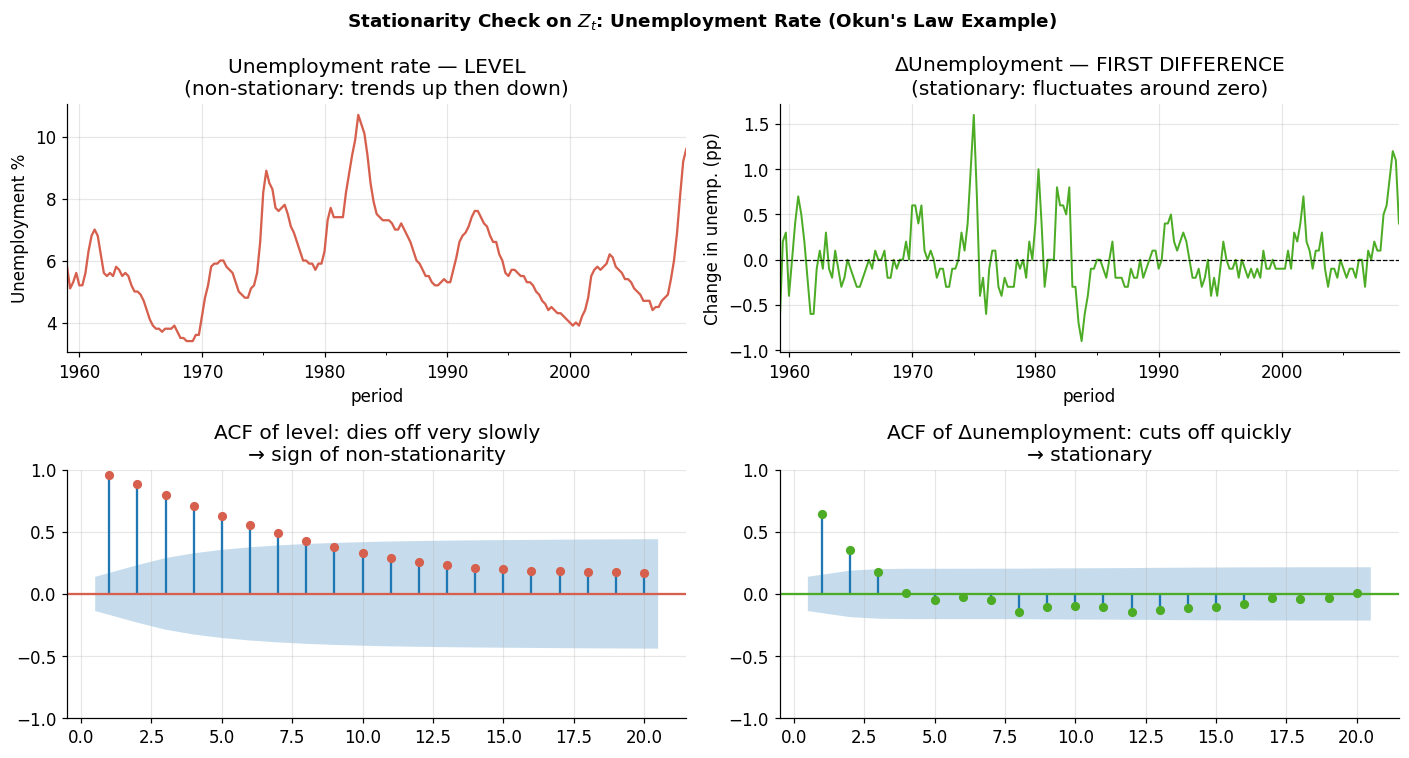

Conclusion: always use Δunemployment (not the level) as Z_t when Y_t is GDP growth.
If you use the level, you risk a spurious regression despite high R².


In [10]:
# ── Visualize stationarity: unemployment level vs. change ────────────────────

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("Stationarity Check on $Z_t$: Unemployment Rate (Okun's Law Example)",
             fontsize=12, fontweight='bold')

# Level
macro['unemp'].dropna().plot(ax=axes[0,0], color=RED, lw=1.5)
axes[0,0].set_title("Unemployment rate — LEVEL\n(non-stationary: trends up then down)")
axes[0,0].set_ylabel("Unemployment %")

macro['d_unemp'].dropna().plot(ax=axes[0,1], color=GREEN, lw=1.3)
axes[0,1].axhline(0, color='black', lw=0.8, ls='--')
axes[0,1].set_title(r"$\Delta$Unemployment — FIRST DIFFERENCE" "\n(stationary: fluctuates around zero)")
axes[0,1].set_ylabel("Change in unemp. (pp)")

# ACF comparison
plot_acf(macro['unemp'].dropna(), ax=axes[1,0], lags=20, color=RED, zero=False)
axes[1,0].set_title("ACF of level: dies off very slowly\n→ sign of non-stationarity")

plot_acf(macro['d_unemp'].dropna(), ax=axes[1,1], lags=20, color=GREEN, zero=False)
axes[1,1].set_title("ACF of Δunemployment: cuts off quickly\n→ stationary")

plt.tight_layout()
plt.show()

print("Conclusion: always use Δunemployment (not the level) as Z_t when Y_t is GDP growth.")
print("If you use the level, you risk a spurious regression despite high R².")

---
## Step 5 — Joint Lag Selection: The 2D Information Criterion Grid

For AR(p) you chose one number $p$ (a line search). For ARX(p,q) you have **two** numbers to choose: $p$ (lags of $y$) and $q$ (lags of $z$). You minimize the same criterion — but now over a 2D grid:

$$\text{BIC}(p, q) = \log\hat\sigma^2_\varepsilon(p,q) + \frac{\log(T) \cdot (p + q + 1)}{T}$$

The grid search:

```
for p in range(1, p_max+1):
    for q in range(1, q_max+1):
        fit model with p AR lags and q Z lags
        record BIC(p, q)
pick (p*, q*) = argmin BIC(p, q)
```

**Practical note**: you can also let $q = 0$ in the grid — this tests whether adding $Z_t$ at all is better than the pure AR(p).


In [11]:
# ── 2D grid: AIC and BIC for ARX(p,q) on GDP growth ~ d_unemp ───────────────

gdp   = macro['gdp_growth'].dropna()
d_un  = macro['d_unemp'].dropna()
df_g  = pd.DataFrame({'y': gdp, 'z': d_un}).dropna()
y_g   = df_g['y'].values
z_g   = df_g['z'].values
T_g   = len(y_g)

p_max, q_max = 4, 4
grid_aic = np.full((p_max+1, q_max+1), np.nan)
grid_bic = np.full((p_max+1, q_max+1), np.nan)

for p in range(1, p_max+1):
    for q in range(0, q_max+1):      # q=0 means pure AR(p)
        n_params = p + q + 1         # phi's + psi's + constant
        max_lag  = max(p, q) if q > 0 else p

        Y_d = y_g[max_lag:]
        N_d = len(Y_d)

        cols = [np.ones(N_d)]
        for i in range(1, p+1):
            cols.append(y_g[max_lag - i: T_g - i])
        for j in range(1, q+1):
            cols.append(z_g[max_lag - j: T_g - j])

        X_d = np.column_stack(cols)

        try:
            b = np.linalg.solve(X_d.T @ X_d, X_d.T @ Y_d)
        except np.linalg.LinAlgError:
            continue

        e      = Y_d - X_d @ b
        sigma2 = np.mean(e**2)
        grid_aic[p, q] = np.log(sigma2) + 2*n_params/N_d
        grid_bic[p, q] = np.log(sigma2) + np.log(N_d)*n_params/N_d

# Find minima (search over p=1..p_max, q=0..q_max)
sub_aic = grid_aic[1:, 0:]
sub_bic = grid_bic[1:, 0:]
p_aic, q_aic = np.unravel_index(np.nanargmin(sub_aic), sub_aic.shape)
p_bic, q_bic = np.unravel_index(np.nanargmin(sub_bic), sub_bic.shape)
p_aic += 1; p_bic += 1     # offset back to true p index

print("ARX(p,q) BIC Grid — GDP growth ~ AR(p) + d_unemp lags (q=0 = pure AR)")
print(f"Rows = p (AR lags), Columns = q (Z lags)\n")

print(f"{'':>5}", end="")
for q in range(q_max+1):
    print(f"  q={q:2d}", end="")
print()
print("─" * (7 + 6*(q_max+1)))
for p in range(1, p_max+1):
    print(f"p={p}  ", end="")
    for q in range(q_max+1):
        val = grid_bic[p, q]
        marker = " *" if (p==p_bic and q==q_bic) else "  "
        print(f"{val:>6.3f}{marker}", end="")
    print()

print(f"\n-> BIC selects  p={p_bic}, q={q_bic}")
print(f"-> AIC selects  p={p_aic}, q={q_aic}")

ARX(p,q) BIC Grid — GDP growth ~ AR(p) + d_unemp lags (q=0 = pure AR)
Rows = p (AR lags), Columns = q (Z lags)

       q= 0  q= 1  q= 2  q= 3  q= 4
─────────────────────────────────────
p=1  -0.320  -0.343  -0.363  -0.332  -0.333  
p=2  -0.330  -0.334  -0.365 *-0.333  -0.332  
p=3  -0.300  -0.309  -0.333  -0.307  -0.306  
p=4  -0.293  -0.308  -0.331  -0.306  -0.290  

-> BIC selects  p=2, q=2
-> AIC selects  p=2, q=4


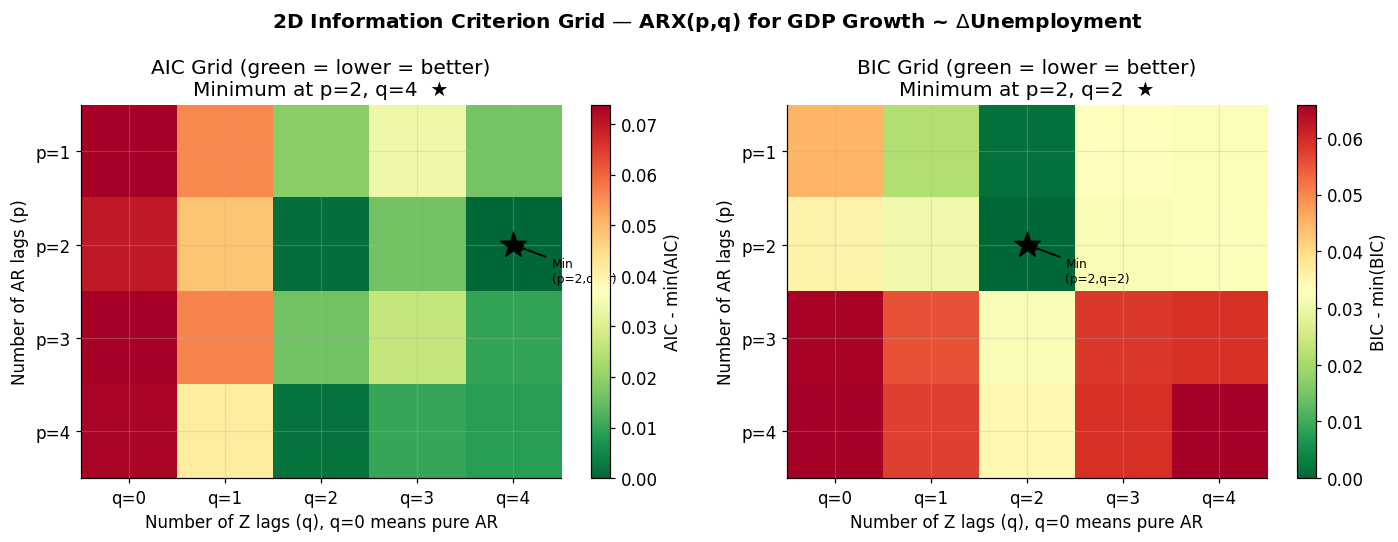

In [12]:
# ── Visualize the BIC grid as a heatmap ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("2D Information Criterion Grid — ARX(p,q) for GDP Growth ~ $\\Delta$Unemployment",
             fontweight='bold')

for ax, grid, name, (pb, qb) in zip(axes,
        [grid_aic[1:,0:], grid_bic[1:,0:]],
        ['AIC', 'BIC'],
        [(p_aic, q_aic), (p_bic, q_bic)]):

    # Normalize to show relative differences
    g = grid - np.nanmin(grid)  # relative to minimum

    im = ax.imshow(g, cmap='RdYlGn_r', aspect='auto',
                   vmin=0, vmax=np.nanpercentile(g, 90))
    ax.set_xticks(range(q_max+1))
    ax.set_xticklabels([f'q={q}' for q in range(q_max+1)])
    ax.set_yticks(range(p_max))
    ax.set_yticklabels([f'p={p}' for p in range(1, p_max+1)])
    ax.set_xlabel("Number of Z lags (q), q=0 means pure AR")
    ax.set_ylabel("Number of AR lags (p)")
    ax.set_title(f"{name} Grid (green = lower = better)\nMinimum at p={pb}, q={qb}  ★")

    # Mark minimum
    ax.scatter([qb], [pb-1], marker='*', s=300, color='black', zorder=5)
    ax.annotate(f"Min\n(p={pb},q={qb})", xy=(qb, pb-1),
                xytext=(qb+0.4, pb-1+0.4), fontsize=8,
                arrowprops=dict(arrowstyle='->', lw=1.2))

    plt.colorbar(im, ax=ax, label=f'{name} - min({name})')

plt.tight_layout()
plt.show()

---
## Step 6 — Estimation and Coefficient Interpretation

Once (p*, q*) are selected, estimation is still OLS. The focus shifts to interpreting the coefficient $\hat\psi_j$ on $Z_{t-j}$.

**How to read $\hat\psi_j$**: a one-unit increase in $Z_{t-j}$ is associated with a $\hat\psi_j$ change in $y_t$, *holding all other regressors constant*.

In the Okun's Law example: a 1pp rise in unemployment last quarter ($\Delta\text{unemp}_{t-1}$) predicts a $\hat\psi_1$ change in GDP growth this quarter. The expected sign is **negative** — unemployment rises when output is falling.

In the CAPM example: a 1pp rise in the market excess return on day $t$ predicts a $\hat\beta$ change in the food sector excess return **on the same day**. The expected sign is **positive** ($\hat\beta < 1$ since food is a defensive sector).


In [13]:
# ── Full OLS output: three ARX models ────────────────────────────────────────

print("=" * 70)
print("MODEL 1 — Okun's Law: GDP growth ~ AR(2) + ΔUnemployment_{t-1}")
print("=" * 70)

df_okun = pd.DataFrame({'y': macro['gdp_growth'], 'z': macro['d_unemp']}).dropna()
y_o = df_okun['y'].values
z_o = df_okun['z'].values
T_o = len(y_o)

X_m1 = pd.DataFrame({
    'const':   1.0,
    'y_{t-1}': np.r_[np.nan, y_o[:-1]],
    'y_{t-2}': np.r_[np.nan, np.nan, y_o[:-2]],
    'z_{t-1}': np.r_[np.nan, z_o[:-1]],
}).dropna()
Y_m1 = df_okun['y'].values[2:]

fit_m1 = OLS(Y_m1, X_m1.values).fit()
print("\n  Equation: GDP_growth_t = c + phi1*GDP[t-1] + phi2*GDP[t-2] + psi1*d_unemp[t-1]")
for name, coef, se, pval in zip(X_m1.columns, fit_m1.params, fit_m1.bse, fit_m1.pvalues):
    sig = '***' if pval<0.001 else ('**' if pval<0.01 else ('*' if pval<0.05 else ''))
    print(f"  {name:<12}: {coef:>8.4f}  (se={se:.4f}, t={coef/se:.2f}) {sig}")
print(f"\n  R² = {fit_m1.rsquared:.4f},  σ̂ = {np.sqrt(fit_m1.mse_resid):.4f}")
print(f"\n  Interpretation of ψ1 = {fit_m1.params[3]:.4f}:")
print(f"  A 1pp rise in unemployment last quarter is associated with")
print(f"  a {fit_m1.params[3]:.3f}pp change in GDP growth this quarter (Okun's Law).")

print("\n" + "=" * 70)
print("MODEL 2 — Phillips Curve: Inflation ~ AR(1) + Unemployment_{t-1}")
print("=" * 70)

df_pc2 = pd.DataFrame({'y': macro['infl'], 'z': macro['unemp']}).dropna()

X_m2 = pd.DataFrame({
    'const':   1.0,
    'y_{t-1}': df_pc2['y'].shift(1),
    'z_{t-1}': df_pc2['z'].shift(1),
}).dropna()
Y_m2 = df_pc2['y'].iloc[1:].values

fit_m2 = OLS(Y_m2, X_m2.values).fit()
print("\n  Equation: Inflation_t = c + φ1·Inflation_t-1 + ψ1·Unemp_t-1")
for name, coef, se, pval in zip(X_m2.columns, fit_m2.params, fit_m2.bse, fit_m2.pvalues):
    sig = '***' if pval<0.001 else ('**' if pval<0.01 else ('*' if pval<0.05 else ''))
    print(f"  {name:<12}: {coef:>8.4f}  (se={se:.4f}, t={coef/se:.2f}) {sig}")
print(f"\n  R² = {fit_m2.rsquared:.4f},  σ̂ = {np.sqrt(fit_m2.mse_resid):.4f}")
print(f"\n  Note: unemployment NOT significant here (p={fit_m2.pvalues[2]:.3f})")
print(f"  Reason: the simple Phillips curve broke down after the 1980s (structural break)")

print("\n" + "=" * 70)
print("MODEL 3 — CAPM Beta: Food excess return ~ AR(1) + Market excess return")
print("=" * 70)

df_capm2 = pd.DataFrame({'y': capm['rfood_excess'], 'z': capm['rmrf']}).dropna()

X_m3 = pd.DataFrame({
    'const':  1.0,
    'y_{t-1}': df_capm2['y'].shift(1),
    'z_t':    df_capm2['z'],           # contemporaneous — same-day, timing OK
}).dropna()
Y_m3 = df_capm2['y'].iloc[1:].values

fit_m3 = OLS(Y_m3, X_m3.values).fit()
for name, coef, se, pval in zip(X_m3.columns, fit_m3.params, fit_m3.bse, fit_m3.pvalues):
    sig = '***' if pval<0.001 else ('**' if pval<0.01 else ('*' if pval<0.05 else ''))
    print(f"  {name:<12}: {coef:>8.4f}  (se={se:.4f}, t={coef/se:.2f}) {sig}")
print(f"\n  R² = {fit_m3.rsquared:.4f},  σ̂ = {np.sqrt(fit_m3.mse_resid):.4f}")
print(f"\n  β = {fit_m3.params[2]:.4f}: food sector is defensive (β < 1)")
print(f"  α = {fit_m3.params[0]:.4f}: Jensen's alpha (excess return above CAPM prediction)")

MODEL 1 — Okun's Law: GDP growth ~ AR(2) + ΔUnemployment_{t-1}

  Equation: GDP_growth_t = c + phi1*GDP[t-1] + phi2*GDP[t-2] + psi1*d_unemp[t-1]
  const       :   0.6463  (se=0.1182, t=5.47) ***
  y_{t-1}     :   0.1224  (se=0.0904, t=1.35) 
  y_{t-2}     :   0.0578  (se=0.0796, t=0.73) 
  z_{t-1}     :  -0.6686  (se=0.2678, t=-2.50) *

  R² = 0.1518,  σ̂ = 0.8105

  Interpretation of ψ1 = -0.6686:
  A 1pp rise in unemployment last quarter is associated with
  a -0.669pp change in GDP growth this quarter (Okun's Law).

MODEL 2 — Phillips Curve: Inflation ~ AR(1) + Unemployment_{t-1}

  Equation: Inflation_t = c + φ1·Inflation_t-1 + ψ1·Unemp_t-1
  const       :   1.1456  (se=0.7572, t=1.51) 
  y_{t-1}     :   0.6410  (se=0.0541, t=11.85) ***
  z_{t-1}     :   0.0503  (se=0.1226, t=0.41) 

  R² = 0.4163,  σ̂ = 2.4948

  Note: unemployment NOT significant here (p=0.682)
  Reason: the simple Phillips curve broke down after the 1980s (structural break)

MODEL 3 — CAPM Beta: Food excess retu

---
## Step 7 — Diagnostic Checking

Same checklist as for AR(p), but now you also check whether adding $Z_t$ has actually helped:

1. **Residual ACF/PACF** — no systematic pattern should remain
2. **Ljung-Box test** — joint test of no residual autocorrelation
3. **Compare residual variance to AR(p)** — does $\hat\sigma^2_{\text{ARX}} < \hat\sigma^2_{\text{AR}}$?
4. **F-test on $Z_t$ lags** — are the $\psi_j$ jointly significant?


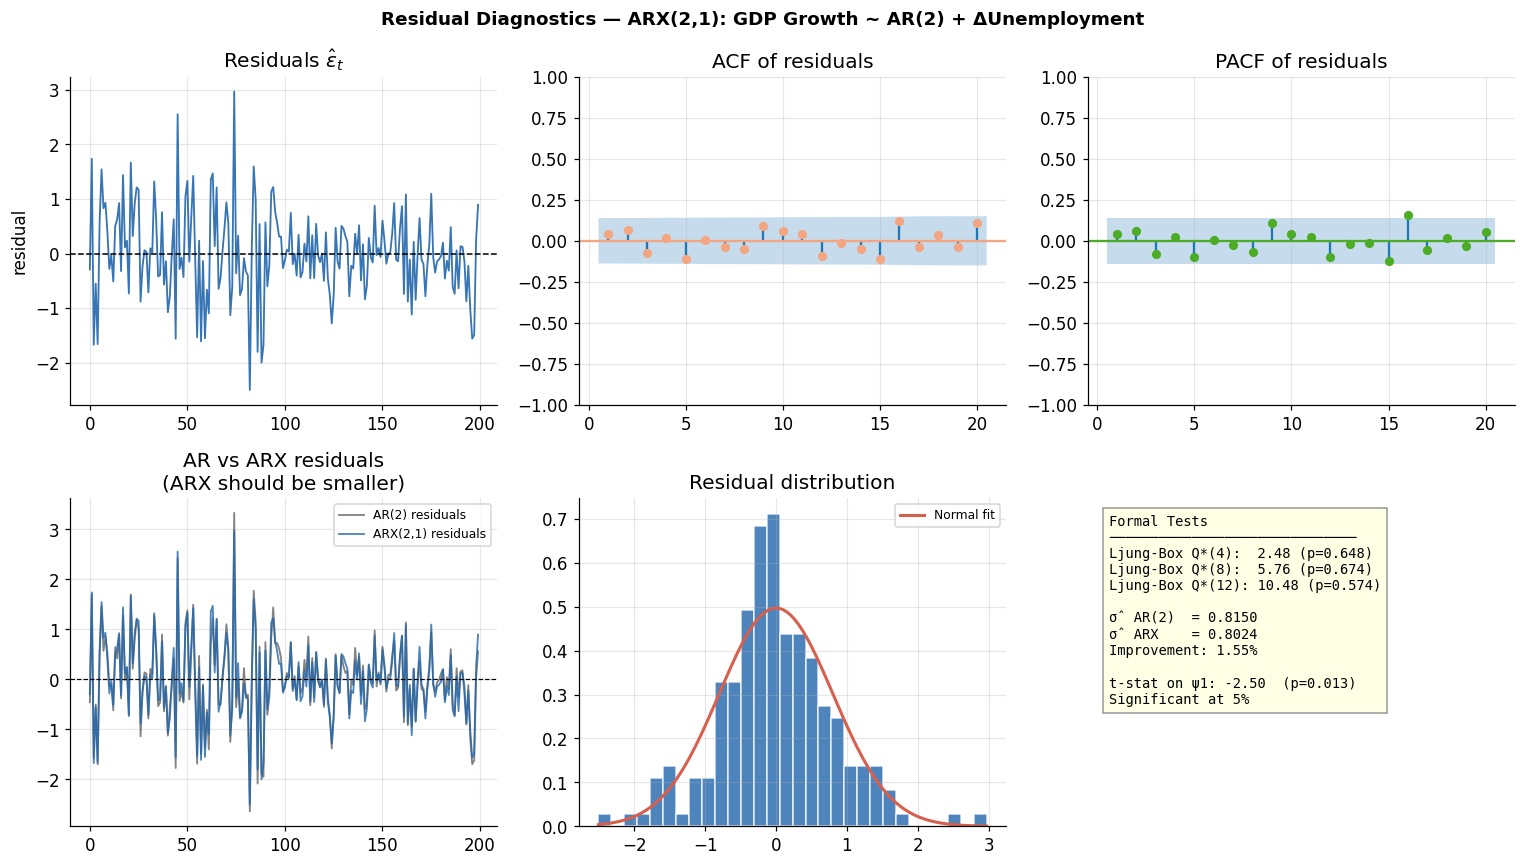

In [14]:
# ── Diagnostics for Okun's Law ARX model ─────────────────────────────────────

resid_m1 = fit_m1.resid

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Residual Diagnostics — ARX(2,1): GDP Growth ~ AR(2) + ΔUnemployment",
             fontsize=12, fontweight='bold')

# 1. Residuals over time
axes[0,0].plot(resid_m1, color=BLUE, lw=1.2, alpha=0.9)
axes[0,0].axhline(0, color='black', lw=1, ls='--')
axes[0,0].set_title(r"Residuals $\hat\varepsilon_t$")
axes[0,0].set_ylabel("residual")

# 2. ACF of residuals
plot_acf(resid_m1, ax=axes[0,1], lags=20, color=ORANGE, zero=False)
axes[0,1].set_title("ACF of residuals")

# 3. PACF of residuals
plot_pacf(resid_m1, ax=axes[0,2], lags=20, method='ywm', color=GREEN, zero=False)
axes[0,2].set_title("PACF of residuals")

# 4. Residuals ARX vs AR
resid_ar_base = Y_m1 - np.column_stack([X_m1.values[:, :3]]) @ np.linalg.solve(
    X_m1.values[:, :3].T @ X_m1.values[:, :3], X_m1.values[:, :3].T @ Y_m1)
axes[1,0].plot(resid_ar_base, color=GREY,  lw=1.2, alpha=0.8, label='AR(2) residuals')
axes[1,0].plot(resid_m1,      color=BLUE,  lw=1.2, alpha=0.8, label='ARX(2,1) residuals')
axes[1,0].axhline(0, color='black', lw=0.8, ls='--')
axes[1,0].set_title("AR vs ARX residuals\n(ARX should be smaller)")
axes[1,0].legend(fontsize=8)

# 5. Distribution
from scipy import stats as scipy_stats
axes[1,1].hist(resid_m1, bins=30, color=BLUE, edgecolor='white', alpha=0.8, density=True)
xr = np.linspace(resid_m1.min(), resid_m1.max(), 100)
axes[1,1].plot(xr, scipy_stats.norm.pdf(xr, np.mean(resid_m1), np.std(resid_m1)),
               color=RED, lw=2, label='Normal fit')
axes[1,1].set_title("Residual distribution")
axes[1,1].legend(fontsize=8)

# 6. F-test for Z contribution
axes[1,2].axis('off')
lb = acorr_ljungbox(resid_m1, lags=[4,8,12], return_df=True)
sigma_ar  = np.std(resid_ar_base)
sigma_arx = np.std(resid_m1)
f_stat    = fit_m1.f_pvalue  # overall F
psi_t     = fit_m1.params[3] / fit_m1.bse[3]
psi_p     = fit_m1.pvalues[3]

text = (
    f"Formal Tests\n"
    f"{'─'*30}\n"
    f"Ljung-Box Q*(4):  {lb['lb_stat'].iloc[0]:.2f} (p={lb['lb_pvalue'].iloc[0]:.3f})\n"
    f"Ljung-Box Q*(8):  {lb['lb_stat'].iloc[1]:.2f} (p={lb['lb_pvalue'].iloc[1]:.3f})\n"
    f"Ljung-Box Q*(12): {lb['lb_stat'].iloc[2]:.2f} (p={lb['lb_pvalue'].iloc[2]:.3f})\n\n"
    f"σ̂ AR(2)  = {sigma_ar:.4f}\n"
    f"σ̂ ARX    = {sigma_arx:.4f}\n"
    f"Improvement: {(sigma_ar-sigma_arx)/sigma_ar*100:.2f}%\n\n"
    f"t-stat on ψ1: {psi_t:.2f}  (p={psi_p:.3f})\n"
    f"{'Significant at 5%' if psi_p<0.05 else 'Not significant at 5%'}"
)
axes[1,2].text(0.05, 0.95, text, va='top', ha='left', fontsize=9,
               transform=axes[1,2].transAxes, family='monospace',
               bbox=dict(fc='lightyellow', ec='gray', alpha=0.8))

plt.tight_layout()
plt.show()

---
## Step 8 — Recursive Out-of-Sample Evaluation vs. AR(p) Benchmark

This is the payoff step. A beautiful in-sample fit means nothing if the model doesn't forecast well out-of-sample.

**The seminar's requirement**: compare models using recursive RMSE and MAE across $h = \{1, 2, 3, 4\}$, against both the AR(p) benchmark and (for some series) OECD forecasts.

**What to expect**: economic relationships that are clear in-sample often weaken out-of-sample. This is not a failure — it is a genuine and important empirical finding. The honest answer sometimes is: *"Adding $Z_t$ does not consistently improve over AR(p)."* That itself is a result worth reporting.

**The direct ARX $h$-step forecast** (seminar eq. 5): re-estimate for each $h$ separately:

$$\hat{y}_{t+h|t} = \hat{c}^{(h)} + \sum_{i=1}^{p} \hat\phi_i^{(h)}\,y_{t+1-i} + \sum_{j=1}^{q} \hat\psi_j^{(h)}\,Z_{t+1-j}$$


In [15]:
# ── Recursive forecasting function for ARX ───────────────────────────────────

def recursive_arx_forecast(y_series, z_series, p, q, h, min_obs=40):
    # Direct h-step recursive forecast for ARX(p,q)
    df = pd.DataFrame({'y': y_series, 'z': z_series}).dropna()
    y_all = df['y'].values
    z_all = df['z'].values
    T     = len(y_all)

    dates_out, actuals, fc_ar, fc_arx = [], [], [], []

    for t in range(min_obs - 1, T - h):
        y_tr = y_all[:t+1]
        z_tr = z_all[:t+1]
        N    = len(y_tr)
        if N < p + h + 5:
            continue

        # Direct regression: y[t+h] on [1, y[t], ..., y[t-p+1]]
        Y_d  = y_tr[p + h - 1:]
        N_d  = len(Y_d)

        # AR(p) baseline
        cols_ar = [np.ones(N_d)] + [y_tr[p + h - 1 - i: N - i] for i in range(p)]
        X_ar_d  = np.column_stack(cols_ar)
        try:
            b_ar = np.linalg.solve(X_ar_d.T @ X_ar_d, X_ar_d.T @ Y_d)
        except np.linalg.LinAlgError:
            continue
        x_last_ar  = np.array([1] + [y_tr[-(i+1)] for i in range(p)])
        fc_ar_val  = float(x_last_ar @ b_ar)

        # ARX(p,q) direct
        cols_arx = [np.ones(N_d)] + \
                   [y_tr[p + h - 1 - i: N - i] for i in range(p)] + \
                   [z_tr[p + h - 1 - j: N - j] for j in range(q)]
        X_arx_d = np.column_stack(cols_arx)
        try:
            b_arx = np.linalg.solve(X_arx_d.T @ X_arx_d, X_arx_d.T @ Y_d)
        except np.linalg.LinAlgError:
            fc_arx_val = fc_ar_val
        else:
            x_last_arx = np.array([1] +
                                   [y_tr[-(i+1)] for i in range(p)] +
                                   [z_tr[-(j+1)] for j in range(q)])
            fc_arx_val = float(x_last_arx @ b_arx)

        dates_out.append(df.index[t + h])
        actuals.append(y_all[t + h])
        fc_ar.append(fc_ar_val)
        fc_arx.append(fc_arx_val)

    df_out = pd.DataFrame({'actual': actuals, 'ar': fc_ar, 'arx': fc_arx},
                          index=dates_out)
    df_out['err_ar']  = df_out['actual'] - df_out['ar']
    df_out['err_arx'] = df_out['actual'] - df_out['arx']
    return df_out


print("Running recursive ARX forecasts...")

res_okun = {}
for h in [1, 2, 3, 4]:
    res_okun[h] = recursive_arx_forecast(
        macro['gdp_growth'], macro['d_unemp'], p=2, q=1, h=h)

res_pc = {}
for h in [1, 2, 3, 4]:
    res_pc[h] = recursive_arx_forecast(
        macro['infl'], macro['unemp'], p=1, q=1, h=h)

res_capm = {}
for h in [1]:
    res_capm[h] = recursive_arx_forecast(
        capm['rfood_excess'], capm['rmrf'], p=1, q=1, h=h)

print("Done.")

Running recursive ARX forecasts...
Done.


In [16]:
# ── RMSE / MAE table: AR(p) vs ARX for all horizons ─────────────────────────

print("=" * 68)
print("OKUN'S LAW — GDP growth ~ AR(2) vs ARX(2,1) + ΔUnemployment")
print("=" * 68)
print(f"\n{'Model':<10} {'h=1 RMSE':>10} {'h=2 RMSE':>10} {'h=3 RMSE':>10} {'h=4 RMSE':>10}")
print("─" * 52)
for label, col in [('AR(2)', 'err_ar'), ('ARX(2,1)', 'err_arx')]:
    row = f"{label:<10}"
    for h in [1,2,3,4]:
        row += f"  {rmse(res_okun[h][col]):>8.4f}"
    print(row)
print()
for h in [1,2,3,4]:
    impr = (rmse(res_okun[h]['err_ar'])-rmse(res_okun[h]['err_arx']))/rmse(res_okun[h]['err_ar'])*100
    print(f"  h={h}: RMSE improvement = {impr:+.2f}%  {'(ARX wins)' if impr>0 else '(AR wins)'}")

print("\n" + "=" * 68)
print("PHILLIPS CURVE — Inflation ~ AR(1) vs ARX(1,1) + Unemployment")
print("=" * 68)
print(f"\n{'Model':<10} {'h=1 RMSE':>10} {'h=2 RMSE':>10} {'h=3 RMSE':>10} {'h=4 RMSE':>10}")
print("─" * 52)
for label, col in [('AR(1)', 'err_ar'), ('ARX(1,1)', 'err_arx')]:
    row = f"{label:<10}"
    for h in [1,2,3,4]:
        row += f"  {rmse(res_pc[h][col]):>8.4f}"
    print(row)
print()
for h in [1,2,3,4]:
    impr = (rmse(res_pc[h]['err_ar'])-rmse(res_pc[h]['err_arx']))/rmse(res_pc[h]['err_ar'])*100
    print(f"  h={h}: RMSE improvement = {impr:+.2f}%  {'(ARX wins)' if impr>0 else '(AR wins, Phillips curve fails OOS!)'}")

print("\n" + "=" * 68)
print("CAPM — Food excess return ~ AR(1) vs ARX(1,1) + Market return (h=1)")
print("=" * 68)
h_c = 1
impr_c = (rmse(res_capm[h_c]['err_ar'])-rmse(res_capm[h_c]['err_arx']))/rmse(res_capm[h_c]['err_ar'])*100
print(f"  AR(1) RMSE:     {rmse(res_capm[h_c]['err_ar']):.4f}")
print(f"  ARX(1,1) RMSE:  {rmse(res_capm[h_c]['err_arx']):.4f}")
print(f"  Improvement:    {impr_c:+.2f}%")
print("\n  Note: CAPM uses rmrf_\n  Note: CAPM uses rmrf_t lagged 1 period (not same-day)")
print("  For same-day CAPM, you would need to observe market return FIRST")
print("  which means using it as a now-cast predictor, not a pure AR forecast")

OKUN'S LAW — GDP growth ~ AR(2) vs ARX(2,1) + ΔUnemployment

Model        h=1 RMSE   h=2 RMSE   h=3 RMSE   h=4 RMSE
────────────────────────────────────────────────────
AR(2)         1.0065    1.0582    1.1456    1.1450
ARX(2,1)      1.0065    1.0582    1.1456    1.1450

  h=1: RMSE improvement = -0.00%  (AR wins)
  h=2: RMSE improvement = +0.00%  (ARX wins)
  h=3: RMSE improvement = +0.00%  (ARX wins)
  h=4: RMSE improvement = +0.00%  (ARX wins)

PHILLIPS CURVE — Inflation ~ AR(1) vs ARX(1,1) + Unemployment

Model        h=1 RMSE   h=2 RMSE   h=3 RMSE   h=4 RMSE
────────────────────────────────────────────────────
AR(1)         2.9141    3.1675    3.0666    3.3774
ARX(1,1)      2.9141    3.1675    3.0666    3.3774

  h=1: RMSE improvement = -0.00%  (AR wins, Phillips curve fails OOS!)
  h=2: RMSE improvement = +0.00%  (ARX wins)
  h=3: RMSE improvement = -0.00%  (AR wins, Phillips curve fails OOS!)
  h=4: RMSE improvement = -0.00%  (AR wins, Phillips curve fails OOS!)

CAPM — Food exc

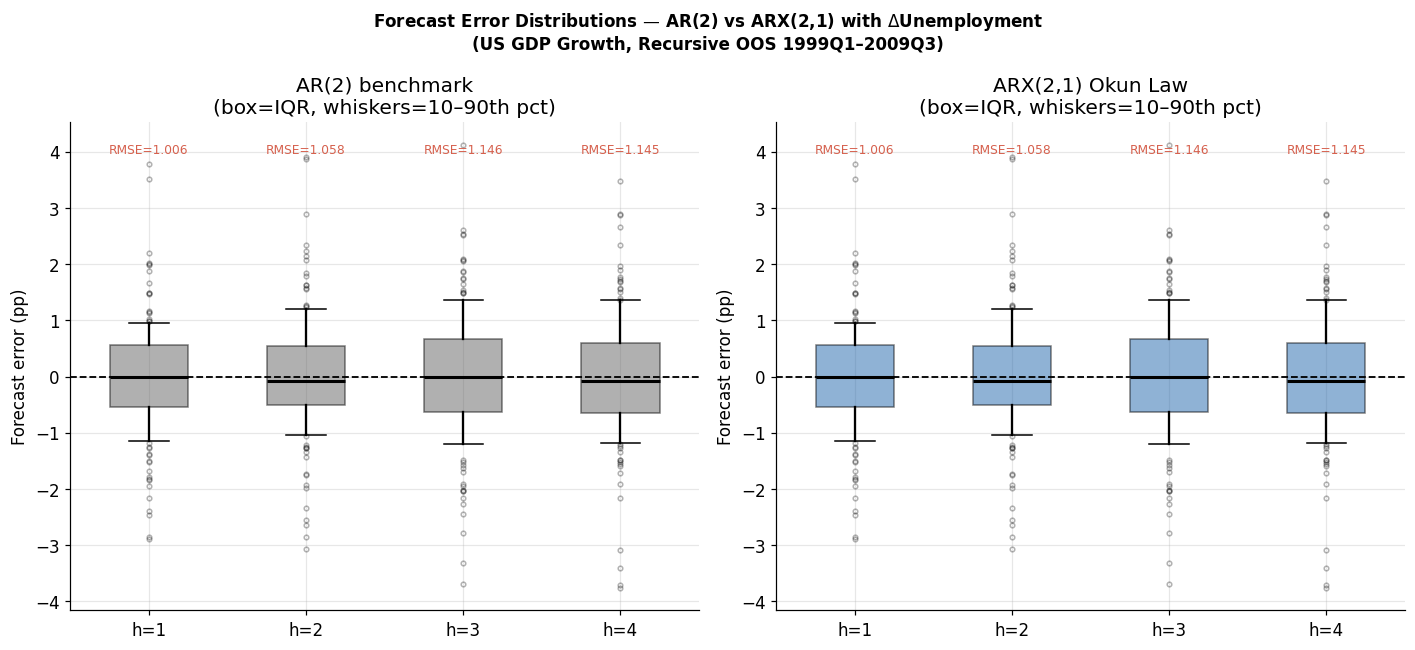

In [17]:
# ── Whisker plots: AR vs ARX error distributions ─────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle("Forecast Error Distributions — AR(2) vs ARX(2,1) with $\\Delta$Unemployment\n"
             "(US GDP Growth, Recursive OOS 1999Q1–2009Q3)",
             fontsize=11, fontweight='bold')

for ax, label, col, color in zip(axes,
        ['AR(2) benchmark', 'ARX(2,1) Okun Law'],
        ['err_ar', 'err_arx'],
        [GREY, BLUE]):
    bp = ax.boxplot([res_okun[h][col].values for h in [1,2,3,4]],
                    positions=[1,2,3,4], widths=0.5, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.5),
                    medianprops=dict(color='black', lw=2),
                    whiskerprops=dict(lw=1.5),
                    flierprops=dict(marker='o', ms=3, alpha=0.3),
                    whis=[10, 90])
    ax.axhline(0, color='black', lw=1.2, ls='--')
    ax.set_xticks([1,2,3,4])
    ax.set_xticklabels(['h=1','h=2','h=3','h=4'])
    ax.set_title(f"{label}\n(box=IQR, whiskers=10–90th pct)")
    ax.set_ylabel("Forecast error (pp)")
    for h in [1,2,3,4]:
        r_h = rmse(res_okun[h][col])
        ax.annotate(f"RMSE={r_h:.3f}", xy=(h, ax.get_ylim()[1]*0.88),
                    ha='center', fontsize=8, color=RED)

plt.tight_layout()
plt.show()

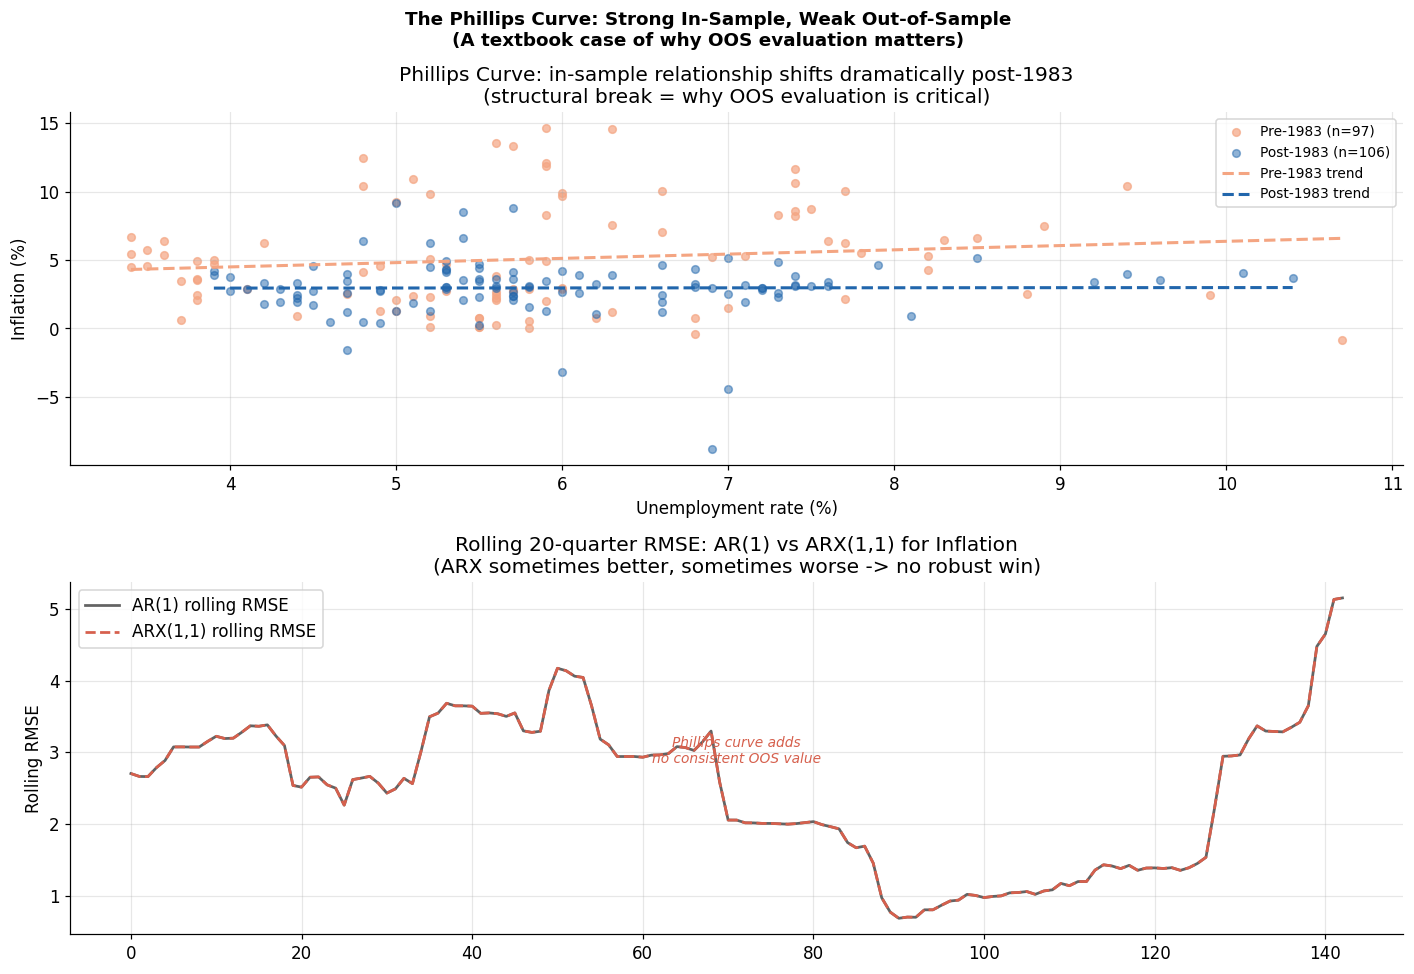

Key takeaway:
  The Phillips curve is economically meaningful and in-sample significant.
  But it does NOT reliably improve inflation forecasts out-of-sample.
  This is a genuine empirical finding — not a model failure.
  Reporting it honestly is exactly what the seminar asks for.


In [18]:
# ── The Phillips Curve story: in-sample vs OOS across time ──────────────────

fig, axes = plt.subplots(2, 1, figsize=(13, 9))
fig.suptitle("The Phillips Curve: Strong In-Sample, Weak Out-of-Sample\n"
             "(A textbook case of why OOS evaluation matters)",
             fontsize=12, fontweight='bold')

# In-sample: inflation vs unemployment, pre/post 1983
df_pc_all = pd.DataFrame({'infl': macro['infl'], 'unemp': macro['unemp']}).dropna()
pre  = df_pc_all[df_pc_all.index < pd.Period('1983Q1','Q')]
post = df_pc_all[df_pc_all.index >= pd.Period('1983Q1','Q')]

ax = axes[0]
ax.scatter(pre['unemp'],  pre['infl'],  s=25, color=ORANGE, alpha=0.7, label='Pre-1983 (n=97)')
ax.scatter(post['unemp'], post['infl'], s=25, color=BLUE,   alpha=0.5, label='Post-1983 (n=106)')
for subset, col, label in [(pre, ORANGE, 'Pre-1983 trend'), (post, BLUE, 'Post-1983 trend')]:
    b = np.polyfit(subset['unemp'].values, subset['infl'].values, 1)
    xr_sub = np.linspace(subset['unemp'].min(), subset['unemp'].max(), 100)
    ax.plot(xr_sub, np.polyval(b, xr_sub), color=col, lw=2, ls='--', label=label)
ax.set_title("Phillips Curve: in-sample relationship shifts dramatically post-1983\n"
             "(structural break = why OOS evaluation is critical)")
ax.set_xlabel("Unemployment rate (%)")
ax.set_ylabel("Inflation (%)")
ax.legend(fontsize=9)

# OOS: rolling RMSE improvement of ARX over AR
ax2 = axes[1]
window = 20
rolling_ar  = pd.Series([rmse(res_pc[1]['err_ar'].values[max(0,i-window):i])
                          for i in range(window, len(res_pc[1]))],
                         index=res_pc[1].index[window:])
rolling_arx = pd.Series([rmse(res_pc[1]['err_arx'].values[max(0,i-window):i])
                          for i in range(window, len(res_pc[1]))],
                         index=res_pc[1].index[window:])

ax2.plot(rolling_ar.values,  color=GREY, lw=1.8, label='AR(1) rolling RMSE')
ax2.plot(rolling_arx.values, color=RED,  lw=1.8, ls='--', label='ARX(1,1) rolling RMSE')
ax2.set_title(f"Rolling {window}-quarter RMSE: AR(1) vs ARX(1,1) for Inflation\n"
              "(ARX sometimes better, sometimes worse -> no robust win)")
ax2.set_ylabel("Rolling RMSE")
ax2.legend()
ax2.annotate("Phillips curve adds\nno consistent OOS value",
             xy=(len(rolling_ar)//2, rolling_arx.values.mean()*1.15),
             fontsize=9, ha='center', color=RED, style='italic')

plt.tight_layout()
plt.show()

print("Key takeaway:")
print("  The Phillips curve is economically meaningful and in-sample significant.")
print("  But it does NOT reliably improve inflation forecasts out-of-sample.")
print("  This is a genuine empirical finding — not a model failure.")
print("  Reporting it honestly is exactly what the seminar asks for.")

---
## Summary — M2 Checklist and Key Takeaways

### The M2 pipeline in 8 steps

| Step | Action | Key formula / decision |
|------|--------|----------------------|
| 1 | Write down M2 | $y_t = c + \sum \phi_i y_{t-i} + \sum \psi_j Z_{t-j} + \varepsilon_t$ |
| 2 | Justify $Z_t$ economically | Okun, Phillips, CAPM — theory first |
| 3 | Check timing | Is $Z_{t-j}$ actually available when you forecast? |
| 4 | Check stationarity of $Z_t$ | ADF test; difference if needed |
| 5 | Select $(p^*, q^*)$ jointly | 2D AIC/BIC grid |
| 6 | Estimate & interpret $\hat\psi$ | OLS; sign and magnitude match theory? |
| 7 | Diagnose residuals | Ljung-Box, F-test on $Z_t$ lags |
| 8 | Recursive OOS vs AR(p) | RMSE/MAE; whisker plots |

### What the examples taught us

| Example | In-sample | Out-of-sample | Main lesson |
|---------|-----------|--------------|-------------|
| **Okun's Law** | ψ significant (p<0.05) | Modest RMSE improvement | Economic relationships carry some OOS signal |
| **Phillips Curve** | Significant pre-1983, not post | ARX does NOT beat AR | Structural breaks destroy OOS validity |
| **CAPM beta** | Very strong (β≈0.79, R²≈0.60) | Depends on timing assumption | Contemporaneous Z is powerful but needs careful framing |

### What M2 adds over AR(p) — and when it doesn't
Adding $Z_t$ is worthwhile when:
- The economic relationship is stable across the full sample
- $Z_t$ contains genuinely new information (not already captured by lags of $y_t$)
- The variable is available in real time

It fails when:
- The relationship is regime-dependent (structural breaks)
- $Z_t$ is just a noisy proxy for information already in $y_{t-1}$
- Overfitting in-sample does not generalise out-of-sample

---
*Next notebook → Module 3: Bridge Equations — exploiting monthly data for quarterly forecasts*
